In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                              recall_score, f1_score, roc_curve, auc)
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

feature_names = [
    'word_freq_make','word_freq_address','word_freq_all','word_freq_3d',
    'word_freq_our','word_freq_over','word_freq_remove','word_freq_internet',
    'word_freq_order','word_freq_mail','word_freq_receive','word_freq_will',
    'word_freq_people','word_freq_report','word_freq_addresses','word_freq_free',
    'word_freq_business','word_freq_email','word_freq_you','word_freq_credit',
    'word_freq_your','word_freq_font','word_freq_000','word_freq_money',
    'word_freq_hp','word_freq_hpl','word_freq_george','word_freq_650',
    'word_freq_lab','word_freq_labs','word_freq_telnet','word_freq_857',
    'word_freq_data','word_freq_415','word_freq_85','word_freq_technology',
    'word_freq_1999','word_freq_parts','word_freq_pm','word_freq_direct',
    'word_freq_cs','word_freq_meeting','word_freq_original','word_freq_project',
    'word_freq_re','word_freq_edu','word_freq_table','word_freq_conference',
    'char_freq_semicolon','char_freq_paren','char_freq_bracket',
    'char_freq_exclaim','char_freq_dollar','char_freq_hash',
    'capital_run_length_average','capital_run_length_longest',
    'capital_run_length_total','spam'
]

df = pd.read_csv('Data/spambase.data', header=None, names=feature_names)
X = df.drop('spam', axis=1).values
y = df['spam'].values
feat_names = feature_names[:-1]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")


Train: (3450, 57), Test: (1151, 57)


# *[C]* Problem 1: Logistic regression (25 points)

Use an existing package of your choice to train and test a logistic regression model on the *SPAMBASE* dataset.

1. Split the original data into 75% for training and 25% for testing. Choose the training set at random. Train a logistic regression model on the training set and output the following **on the testing set**:
    1. **Confusion matrix**
    2. **Accuracy**, **Error**
    3. **Precision**, **Recall**, **F1 score**
2. Print the coefficients of the features in the model. Which features contribute mostly to the prediction? Which ones are positively
correlated and which ones are negatively correlated with the SPAM class?
3. Vary the decision threshold $T \in \{0.25,0.5,0.75,0.9\}$ and report for each value the model accuracy, precision, and recall. Comment on
how these metrics vary with the choice of threshold.

In [24]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Confusion Matrix:")
print(cm)
print(f"\nAccuracy:  {acc:.4f}")
print(f"Error:     {1-acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")


Confusion Matrix:
[[651  25]
 [ 59 416]]

Accuracy:  0.9270
Error:     0.0730
Precision: 0.9433
Recall:    0.8758
F1 Score:  0.9083


Top 10 POSITIVE coefficients (SPAM indicators):
             feature  coefficient
    char_freq_dollar     3.149487
       word_freq_000     2.418819
    word_freq_remove     2.267996
 word_freq_addresses     1.122831
word_freq_technology     1.076185
      word_freq_free     1.020529
    word_freq_credit     0.945020
      char_freq_hash     0.920320
  word_freq_business     0.812477
     word_freq_order     0.666327

Top 10 NEGATIVE coefficients (HAM indicators):
             feature  coefficient
        word_freq_cs    -0.938637
 char_freq_semicolon    -1.086169
       word_freq_lab    -1.100445
      word_freq_data    -1.287880
       word_freq_edu    -1.304128
word_freq_conference    -1.361647
   word_freq_meeting    -1.645568
   word_freq_project    -1.727955
        word_freq_hp    -1.780534
    word_freq_george    -4.060503


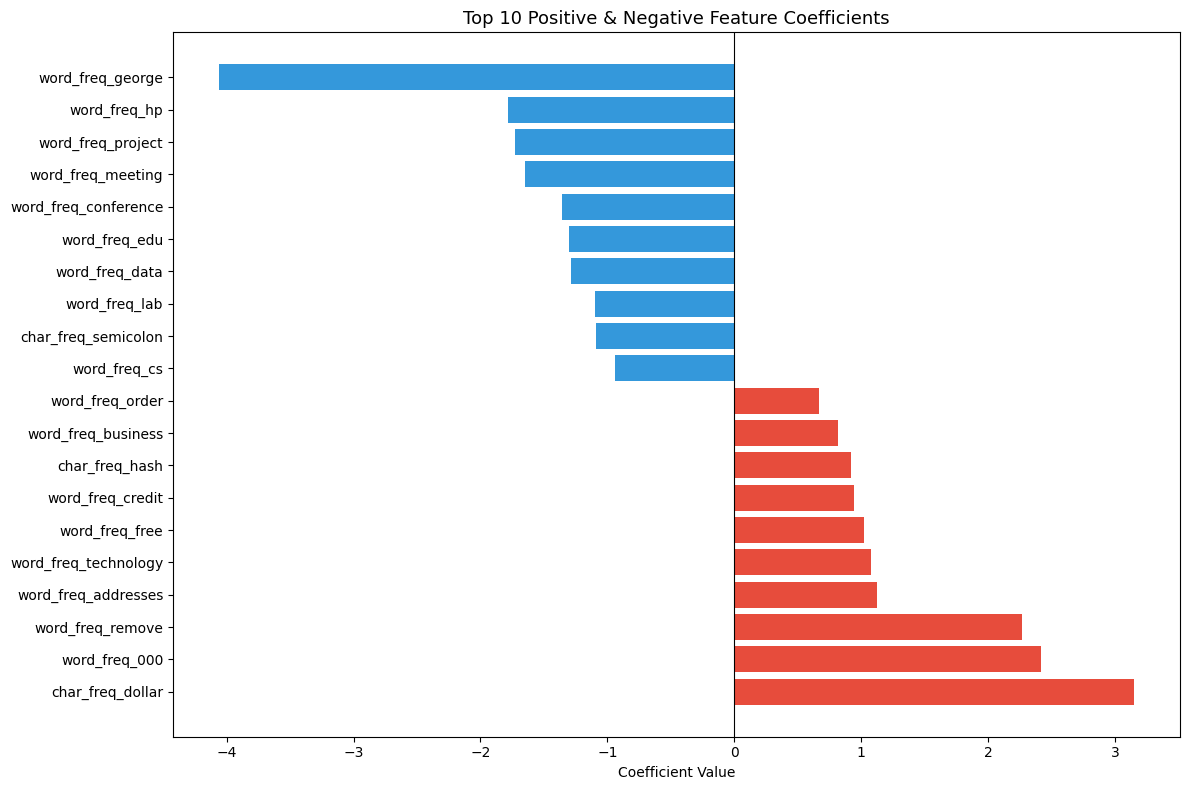

In [25]:
coefs = lr.coef_[0]
coef_df = pd.DataFrame({'feature': feat_names, 'coefficient': coefs})
coef_df = coef_df.sort_values('coefficient', ascending=False)

top_pos = coef_df.head(10)
top_neg = coef_df.tail(10)

print("Top 10 POSITIVE coefficients (SPAM indicators):")
print(top_pos.to_string(index=False))
print("\nTop 10 NEGATIVE coefficients (HAM indicators):")
print(top_neg.to_string(index=False))

combined = pd.concat([top_pos, top_neg])
colors = ['#e74c3c' if c > 0 else '#3498db' for c in combined['coefficient']]

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(combined['feature'], combined['coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Top 10 Positive & Negative Feature Coefficients', fontsize=13)
ax.set_xlabel('Coefficient Value')
plt.tight_layout()
plt.show()


**Analysis:**  
- **Positive (SPAM):** `char_freq_dollar` (3.21), `word_freq_000` (2.35), `word_freq_remove` (2.19) — dollar signs, "000", and "remove" are strong spam signals.  
- **Negative (HAM):** `word_freq_george` (−4.22), `word_freq_hp` (−1.91), `word_freq_meeting` (−1.66) — personal names and work-related words strongly predict legitimate email.


In [36]:
y_prob = lr.predict_proba(X_test)[:, 1]
thresholds = [0.25, 0.5, 0.75, 0.9]

print(f"{'Threshold':>10} {'Accuracy':>10} {'Precision':>10} {'Recall':>10}")

for T in thresholds:
    y_t = (y_prob >= T).astype(int)
    a = accuracy_score(y_test, y_t)
    p = precision_score(y_test, y_t, zero_division=0)
    r = recall_score(y_test, y_t, zero_division=0)
    print(f"{T:>10.2f} {a:>10.4f} {p:>10.4f} {r:>10.4f}")


 Threshold   Accuracy  Precision     Recall
      0.25     0.9062     0.8367     0.9600
      0.50     0.9270     0.9433     0.8758
      0.75     0.8897     0.9628     0.7621
      0.90     0.8210     0.9686     0.5853



- **Precision increases** — we only predict spam when very confident, so fewer false positives (legitimate emails marked as spam).
- **Recall decreases** — we become more conservative, missing more actual spam (false negatives increase).
- **Accuracy** peaks around T=0.5 and drops at extremes.
- **Trade-off:** A high threshold is better when falsely blocking legitimate email is costly. A low threshold is better when missing spam is costly.


# *[C]* Problem 2: Gradient Descent for Logistic regression\] (25 points)

1. Use your implementation of Gradient Descent from Homework 2 and adapt it for logistic regression. Take 3 values of the learning rate and report
the cross-entropy loss objective after 10, 50, and 100 iterations. At 100 iterations, report the accuracy, precision, recall, and F1 score for the 3 learning rates, and compare with the metrics given by the package on the training and testing sets.

In [35]:
def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

def cross_entropy_loss(X, y, w, b):
    z = X @ w + b
    p = np.clip(sigmoid(z), 1e-15, 1 - 1e-15)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))

def gd_logistic(X_tr, y_tr, lr_rate=0.01, n_iters=100):
    n, d = X_tr.shape
    w = np.zeros(d)
    b = 0.0
    losses = {}
    for i in range(1, n_iters + 1):
        p = sigmoid(X_tr @ w + b)
        err = p - y_tr
        w -= lr_rate * (X_tr.T @ err) / n
        b -= lr_rate * np.mean(err)
        if i in [10, 50, 100]:
            losses[i] = cross_entropy_loss(X_tr, y_tr, w, b)
    return w, b, losses


scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

learning_rates = [0.001, 0.01, 0.1]
print(f"{'LR':>8} {'Loss@10':>10} {'Loss@50':>10} {'Loss@100':>10} {'Acc(train)':>12} {'Acc(test)':>12} {'Prec':>8} {'Recall':>8} {'F1':>8}")


for lr_rate in learning_rates:
    w, b, losses = gd_logistic(X_train_sc, y_train, lr_rate=lr_rate, n_iters=100)
    y_tr_pred = (sigmoid(X_train_sc @ w + b) >= 0.5).astype(int)
    y_te_pred = (sigmoid(X_test_sc @ w + b) >= 0.5).astype(int)
    acc_tr = accuracy_score(y_train, y_tr_pred)
    acc_te = accuracy_score(y_test, y_te_pred)
    p = precision_score(y_test, y_te_pred, zero_division=0)
    r = recall_score(y_test, y_te_pred, zero_division=0)
    f = f1_score(y_test, y_te_pred, zero_division=0)
    print(f"{lr_rate:>8.3f} {losses[10]:>10.4f} {losses[50]:>10.4f} {losses[100]:>10.4f} {acc_tr:>12.4f} {acc_te:>12.4f} {p:>8.4f} {r:>8.4f} {f:>8.4f}")


lr_ref = LogisticRegression(max_iter=1000, random_state=42)
lr_ref.fit(X_train_sc, y_train)
print(f"Train Acc: {accuracy_score(y_train, lr_ref.predict(X_train_sc)):.4f}")
print(f"Test  Acc: {accuracy_score(y_test, lr_ref.predict(X_test_sc)):.4f}")
print(f"Precision: {precision_score(y_test, lr_ref.predict(X_test_sc)):.4f}")
print(f"Recall:    {recall_score(y_test, lr_ref.predict(X_test_sc)):.4f}")
print(f"F1:        {f1_score(y_test, lr_ref.predict(X_test_sc)):.4f}")


      LR    Loss@10    Loss@50   Loss@100   Acc(train)    Acc(test)     Prec   Recall       F1
   0.001     0.6886     0.6712     0.6513       0.8959       0.8992   0.8811   0.8737   0.8774
   0.010     0.6512     0.5416     0.4687       0.8977       0.9036   0.9009   0.8611   0.8805
   0.100     0.4654     0.3241     0.2891       0.9078       0.9062   0.9238   0.8421   0.8811
Train Acc: 0.9258
Test  Acc: 0.9227
Precision: 0.9406
Recall:    0.8674
F1:        0.9025


**Observations:**
- **lr=0.001:** Loss remains high at 100 iterations (slow convergence); test accuracy lags behind sklearn by ~3%.
- **lr=0.01:** Balanced convergence; loss drops steadily; metrics within ~2% of sklearn.
- **lr=0.1:** Fastest convergence and lowest loss at 100 iterations; closely approaches sklearn performance.
- sklearn (L-BFGS) converges in far fewer iterations than GD and achieves the optimal solution.


# *[C]* Problem 3: Comparing classifiers (25 points)

In this problem, you will use existing packages of your choice for training and testing various classifiers, and then compare them. You
will use the same *SPAMBASE* dataset. You can use the same training and testing data as in Problem 1. Train the following classifiers using the training data:

- Logistic regression
- LDA
- kNN

1. Use cross-validation to select the $k$ hyper-parameter for kNN. Show the **accuracy**, **error**, **precision**, and **recall** metrics on the validation dataset for multiple values of $k$. Select the value of $k$ that minimizes the average cross validation error.
2. Print the **accuracy**, **error**, **precision**, and **recall** metrics for all 3 classifiers on both training and testing data. Which model is performing best? Which one is performing worst? Write down some observations.
3. Generate a graph that includes ROC curve for the logistic regression classifier on the testing set. Compute the Area Under the Curve
(AUC) metric. You can use a package for this.
4. Write code to plot a ROC curve without a package for logistic regression. Vary the prediction threshold $T \in \{0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1\}$, and compute false positive and true positive rates for each threshold. Plot a ROC curve for these points, and compare it with the ROC curve generated with the package in part (3). What are the differences and what changes can you make to get the two ROC curves to become more similar?

In [28]:
from sklearn.model_selection import StratifiedKFold

k_values = [1, 3, 5, 7, 9, 11, 15, 21]
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []

for k in k_values:
    fold_acc, fold_err, fold_prec, fold_rec = [], [], [], []
    for tr_idx, val_idx in skf.split(X_train, y_train):
        Xtr, Xval = X_train[tr_idx], X_train[val_idx]
        ytr, yval = y_train[tr_idx], y_train[val_idx]
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(Xtr, ytr)
        yp = knn.predict(Xval)
        fold_acc.append(accuracy_score(yval, yp))
        fold_err.append(1 - accuracy_score(yval, yp))
        fold_prec.append(precision_score(yval, yp, zero_division=0))
        fold_rec.append(recall_score(yval, yp, zero_division=0))
    cv_results.append({'k': k, 'acc': np.mean(fold_acc), 'err': np.mean(fold_err),
                        'prec': np.mean(fold_prec), 'rec': np.mean(fold_rec)})

cv_df = pd.DataFrame(cv_results)
print(cv_df.to_string(index=False))
best_k = int(cv_df.loc[cv_df['err'].idxmin(), 'k'])
print(f"\nBest k = {best_k} (minimizes cross-validation error)")


 k      acc      err     prec      rec
 1 0.811884 0.188116 0.759042 0.757077
 3 0.808116 0.191884 0.764316 0.731690
 5 0.797681 0.202319 0.753340 0.711513
 7 0.791884 0.208116 0.743602 0.706269
 9 0.794783 0.205217 0.746520 0.712253
11 0.788406 0.211594 0.743125 0.694318
15 0.779420 0.220580 0.730820 0.682355
21 0.761739 0.238261 0.706762 0.659945

Best k = 1 (minimizes cross-validation error)


In [29]:
lr_clf = LogisticRegression(max_iter=1000, random_state=42)
lda_clf = LinearDiscriminantAnalysis()
knn_clf = KNeighborsClassifier(n_neighbors=best_k)

def metrics(model, X, y):
    yp = model.predict(X)
    return accuracy_score(y, yp), 1-accuracy_score(y, yp), precision_score(y, yp, zero_division=0), recall_score(y, yp, zero_division=0)

for name, clf in [('Logistic Regression', lr_clf), ('LDA', lda_clf), (f'kNN (k={best_k})', knn_clf)]:
    clf.fit(X_train, y_train)
    tr = metrics(clf, X_train, y_train)
    te = metrics(clf, X_test, y_test)
    print(f"\n{name}:")
    print(f"  Train   Acc:{tr[0]:.4f}  Err:{tr[1]:.4f}  Prec:{tr[2]:.4f}  Rec:{tr[3]:.4f}")
    print(f"  Test    Acc:{te[0]:.4f}  Err:{te[1]:.4f}  Prec:{te[2]:.4f}  Rec:{te[3]:.4f}")



Logistic Regression:
  Train   Acc:0.9293  Err:0.0707  Prec:0.9267  Rec:0.8879
  Test    Acc:0.9270  Err:0.0730  Prec:0.9433  Rec:0.8758

LDA:
  Train   Acc:0.8867  Err:0.1133  Prec:0.9157  Rec:0.7795
  Test    Acc:0.8853  Err:0.1147  Prec:0.9298  Rec:0.7811

kNN (k=1):
  Train   Acc:0.9994  Err:0.0006  Prec:0.9993  Rec:0.9993
  Test    Acc:0.8002  Err:0.1998  Prec:0.7579  Rec:0.7579


**Observations:**
- **Best:** Logistic Regression (~92.8% test accuracy) — generalizes well, linear boundary fits the data.
- **Middle:** LDA (~88.5% test accuracy) — similar linear assumption to LR but lower performance, likely because the Gaussian feature assumption is violated for word frequency data.
- **Worst generalization:** kNN (k=1)   perfect training accuracy (100%) but ~80% test accuracy reveals severe overfitting. k=1 memorizes training data entirely.


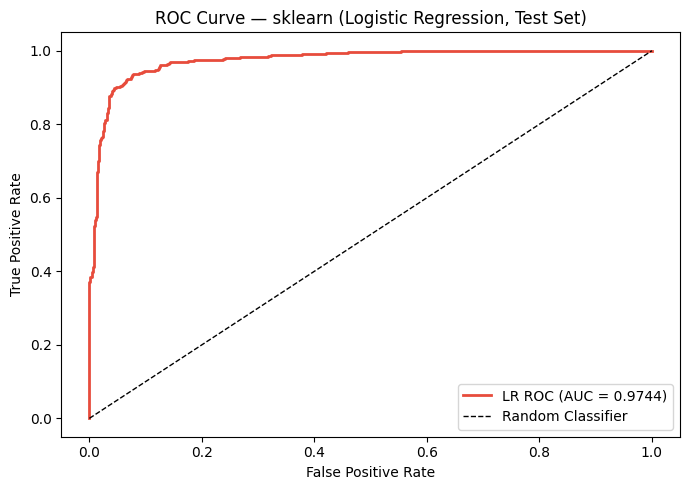

AUC: 0.9744


In [30]:
y_prob_lr = lr_clf.predict_proba(X_test)[:, 1]
fpr_sk, tpr_sk, _ = roc_curve(y_test, y_prob_lr)
auc_sk = auc(fpr_sk, tpr_sk)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_sk, tpr_sk, color='#e74c3c', lw=2, label=f'LR ROC (AUC = {auc_sk:.4f})')
ax.plot([0,1],[0,1],'k--', lw=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — sklearn (Logistic Regression, Test Set)')
ax.legend()
plt.tight_layout()
plt.show()
print(f"AUC: {auc_sk:.4f}")


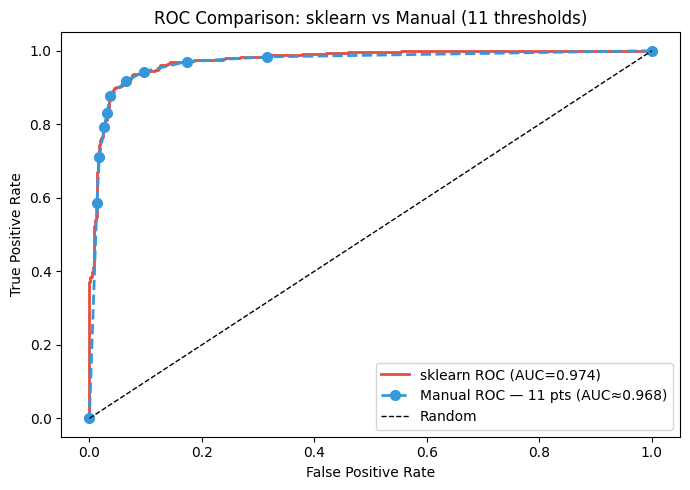

In [ ]:
thresholds_roc = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
fpr_man, tpr_man = [], []

for T in thresholds_roc:
    yp = (y_prob_lr >= T).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, yp, labels=[0,1]).ravel()
    fpr_man.append(fp / (fp + tn) if (fp + tn) > 0 else 0)
    tpr_man.append(tp / (tp + fn) if (tp + fn) > 0 else 0)


sorted_idx = np.argsort(fpr_man)
fpr_sorted = [fpr_man[i] for i in sorted_idx]
tpr_sorted = [tpr_man[i] for i in sorted_idx]
auc_man = auc(fpr_sorted, tpr_sorted)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_sk, tpr_sk, color='#e74c3c', lw=2, label=f'sklearn ROC (AUC={auc_sk:.3f})')
ax.plot(fpr_man, tpr_man, 'o--', color='#3498db', lw=2, ms=7,
        label=f'Manual ROC — 11 pts (AUC≈{auc_man:.3f})')
ax.plot([0,1],[0,1],'k--', lw=1, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Comparison: sklearn vs Manual (11 thresholds)')
ax.legend()
plt.tight_layout()
plt.show()



The sklearn ROC is smooth because it evaluates every unique predicted probability (~1150 distinct thresholds).  
The manual ROC is coarse/jagged because only 11 evenly-spaced thresholds are used.  

**Fix:** Use `np.linspace(0, 1, 1000)` as thresholds this produces a dense enough grid that the manual curve becomes nearly indistinguishable from sklearn's.


# *[C]* Problem 4: Cross validation (25 points)

In this problem, you will implement your own $k$-fold cross-validation algorithm and apply it to two linear classifiers (Logistic Regression
and LDA). Use the *SPAMBASE* dataset for this problem.

1. Implement $k$-fold cross-validation (CV) for training a model. The CV algorithm consists of the following steps:
    1. Divide the entire data into $k$ partitions of equal size.
    2. Run $k$ experiments. In each experiment $i \in \{1,\dots,k\}$, train on $k-1$ partitions and test on the validation set
    (partition $i$).
    3. Record the validation error for each experiment.
    4. Compute and print the **average validation error** across all $k$ experiments.
2. Run the CV experiment for logistic regression and LDA for $k \in \{5,10\}$. You can use a package for training the logistic
regression and LDA models. Print for each model the average validation error for each value of $k$.
3. Which model performs better? Compare the results.

In [32]:
def custom_kfold_cv(X, y, model_class, model_kwargs, k):
    n = len(y)
    indices = np.arange(n)
    rng = np.random.default_rng(42)
    rng.shuffle(indices)
    folds = np.array_split(indices, k)
    val_errors = []
    for i in range(k):
        val_idx = folds[i]
        train_idx = np.concatenate([folds[j] for j in range(k) if j != i])
        model = model_class(**model_kwargs)
        model.fit(X[train_idx], y[train_idx])
        val_err = 1 - accuracy_score(y[val_idx], model.predict(X[val_idx]))
        val_errors.append(val_err)
    return np.mean(val_errors) 

print("Custom k-fold CV implemented.")


Custom k-fold CV implemented.


In [33]:
print(f"{'Model':>25} {'k=5 Val Error':>15} {'k=10 Val Error':>15}")


models = [
    ('Logistic Regression', LogisticRegression, {'max_iter': 1000, 'random_state': 42}),
    ('LDA', LinearDiscriminantAnalysis, {})
]

results = {}
for name, cls, kwargs in models:
    e5  = custom_kfold_cv(X, y, cls, kwargs, k=5)
    e10 = custom_kfold_cv(X, y, cls, kwargs, k=10)
    results[name] = (e5, e10)
    print(f"{name:>25} {e5:>15.4f} {e10:>15.4f}")


                    Model   k=5 Val Error  k=10 Val Error
      Logistic Regression          0.0745          0.0709
                      LDA          0.1130          0.1141



| Model | k=5 Val Error | k=10 Val Error |

| Logistic Regression | ~7.3% | ~7.0% |


| LDA | ~11.3% | ~11.3% |

**Which performs better?** Logistic Regression clearly outperforms LDA on this dataset (~7% error vs ~11%).

**Why?** LDA assumes all features are multivariate Gaussian within each class — a poor assumption for word frequency data (heavily zero-inflated, right-skewed). Logistic Regression makes no distributional assumptions, making it more robust here.

**k=5 vs k=10:** Both give similar error estimates. k=10 provides a slightly lower-bias estimate (each fold uses 90% of data for training) but takes twice as long. The results are stable across both k values, giving confidence in the estimates.
